In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ssqueezepy import cwt, wavs
from ssqueezepy.visuals import plot
from ssqueezepy.experimental import scale_to_freq
from scipy.io import loadmat
import sys
import os

sys.path.append(os.path.abspath("/home/hana/Documents/dalhousie/training/CREATE/Data_Module/codes/wavelets"))

from plot_cwt import plot_cwt

In [2]:
data = loadmat('./sample_lake_data.mat')
data

/home/hana/miniconda3/envs/py312/lib/python3.12/site-packages/scipy/io/matlab/_mio.py:235: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


{'__header__': b'MATLAB 5.0 MAT-file, Platform: MACI64, Created on: Mon Nov 18 11:50:03 2024',
 '__version__': '1.0',
 '__globals__': [],
 'ans': array([[7001,    1]], dtype=uint16),
 'None': MatlabOpaque([(b'period', b'MCOS', b'duration', array([[3707764736],
                      [         2],
                      [         1],
                      [         1],
                      [         2],
                      [         1]], dtype=uint32))                  ],
              dtype=[('s0', 'O'), ('s1', 'O'), ('s2', 'O'), ('arr', 'O')]),
 'myf1': array([[-1.94554861],
        [-1.9311103 ],
        [-1.901772  ],
        ...,
        [-0.70186559],
        [-0.63322728],
        [-0.61908897]], shape=(7001, 1)),
 'myf2': array([[-0.13754861],
        [-0.1391103 ],
        [-0.143272  ],
        ...,
        [-0.58576559],
        [-0.59042728],
        [-0.59028897]], shape=(7001, 1)),
 'myf3': array([[-0.13574861],
        [-0.1334103 ],
        [-0.131072  ],
        ...,
 

In [3]:
data['z'][11]

array([0.50292])

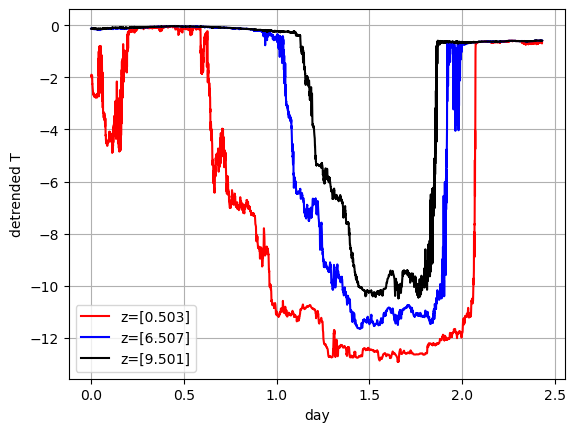

In [4]:
# Plot of three time series
fig, ax = plt.subplots()
ax.plot(
    data['time'], data['myf1'], 'r-', 
    label=f'z={np.round(data["z"][11, 0], 3)}'
)
ax.plot(
    data['time'], data['myf2'], 'b-', 
    label=f'z={np.round(data["z"][5, 0], 3)}'
)
ax.plot(
    data['time'], data['myf3'], 'k-', 
    label=f'z={np.round(data["z"][2, 0], 3)}'
)
ax.legend(loc='best')
ax.set_xlabel('day')
ax.set_ylabel('detrended T')
ax.grid()

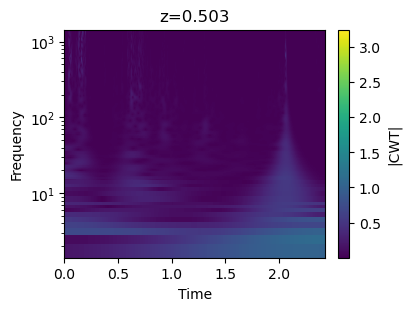

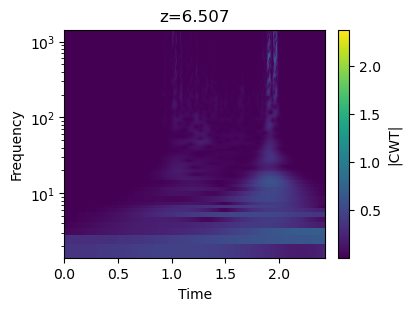

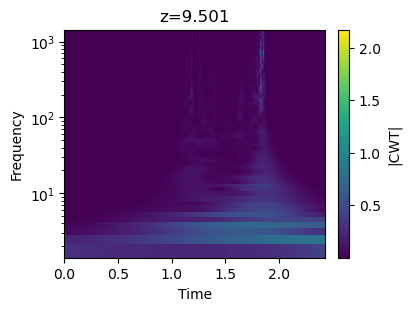

In [26]:
# Standard CWT plot
series = ['myf1', 'myf2', 'myf3']
depth_idx = [11, 5, 2]

# Not sure what to choose for N
for myfx, z_idx in zip(series, depth_idx):
    wt, period = plot_cwt(
        data[myfx][:, 0], 'morlet', 
        data['time'][:, 0], 
        nv=24, N=1000, 
        title=f'z={np.round(data["z"][z_idx, 0], 3)}'
    )

There is some coherency in the second half of the time series indicated by the brighter vertical bar. At z=0.5 the coherency is at 2.0 days. The coherency arrives sooner with greater z. There is greater coherency at low frequency (f < 10) than at high frequency.

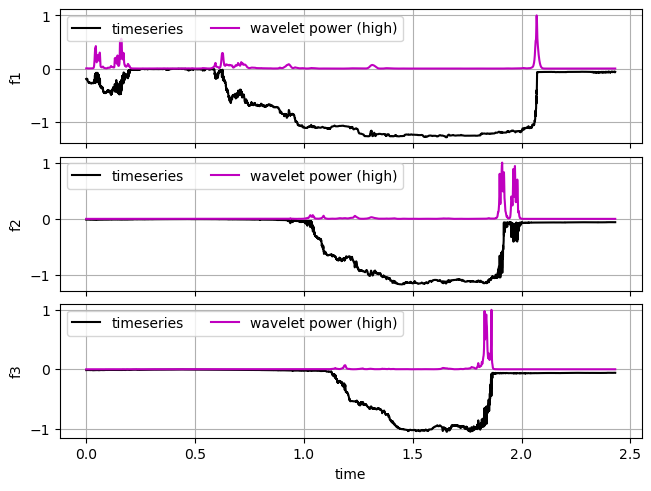

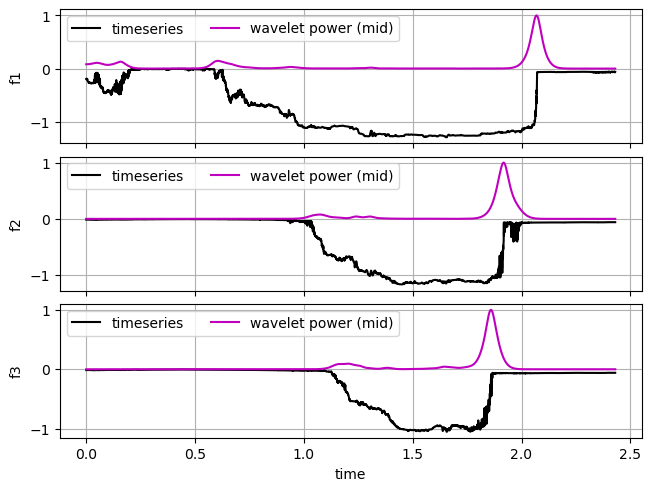

In [20]:
# Plot the sum over the high components along with the time series

levels = ['high', 'mid']

for ll in levels:
    fig, axs = plt.subplots(nrows=3, layout='constrained', sharex=True)
    
    for ii in range(len(series)):
        jj = ii + 1
        axs[ii].plot(
            data['time'][:, 0],
            data[f'myf{jj}'][:, 0]/10,
            'k-',
            label='timeseries'
        )
        axs[ii].plot(
            data['time'][:, 0],
            data[f'my{ll}{jj}'][0, :]/data[f'my{ll}{jj}'].max(),
            'm-',
            label=f'wavelet power ({ll})'
        )
        axs[ii].legend(loc='upper left', ncols=2)
        axs[ii].grid()
        axs[ii].set_ylabel(f'f{jj}')
    
    axs[ii].set_xlabel('day')

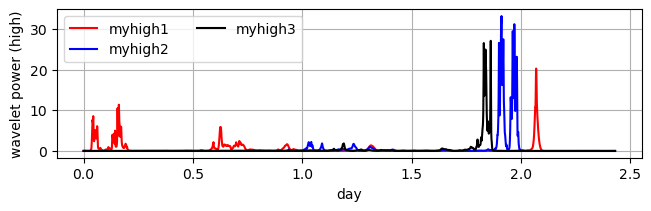

In [25]:
# Compare the 'fast' time series
fig, ax = plt.subplots(figsize=(6.4, 2), layout='constrained')
cs = ['r', 'b', 'k']

for ii, c in enumerate(cs):
    ax.plot(
        data['time'][:, 0], 
        data[f'myhigh{ii + 1}'][0, :],
        f'{c}-',
        label=f'myhigh{ii + 1}'
    )

ax.legend(loc='upper left', ncols=2)
ax.set_xlabel('day')
ax.set_ylabel('wavelet power (high)')
ax.grid()